## **PSM analysis**

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
import pandas as pd

train = pd.read_csv('/content/drive/MyDrive/Project/CTproject/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Project/CTproject/test.csv')
label = pd.read_csv('/content/drive/MyDrive/Project/CTproject/test_label.csv')

print("====== TRAIN SHAPE ======")
print(train.shape)
print(train.head())

print("\n====== TEST SHAPE ======")
print(test.shape)
print(test.head())

print("\n====== TEST LABEL SHAPE ======")
print(label.shape)
print(label.head())


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
====== TRAIN SHAPE ======
(132481, 26)
   timestamp_(min)  feature_0  feature_1  feature_2  feature_3  feature_4  \
0              0.0   0.732689   0.761748   0.606848   0.488746   0.424310   
1              1.0   0.732799   0.761855   0.607133   0.488781   0.432008   
2              2.0   0.732938   0.761594   0.606895   0.488791   0.418858   
3              3.0   0.732893   0.761656   0.606478   0.488802   0.417896   
4              4.0   0.732788   0.761573   0.606777   0.488800   0.421103   

   feature_5  feature_6  feature_7  feature_8  ...  feature_15  feature_16  \
0   0.403609   0.519318   0.398792   0.451453  ...    0.318797    0.451856   
1   0.410256   0.511364   0.402568   0.455657  ...    0.321463    0.456123   
2   0.407724   0.488636   0.396526   0.456104  ...    0.347219    0.456692   
3   0.404242   0.500000   0.405589   0.460020  ...    0

In [ ]:
label.columns = ["timestamp_(min)", "label"]

train['State'] = 'PSM'
test['State'] = 'PSM'

base = pd.Timestamp("2020-01-01 00:00:00")

train['Date'] = base + pd.to_timedelta(train['timestamp_(min)'], unit='m')
test['Date'] = base + pd.to_timedelta(test['timestamp_(min)'], unit='m')
label['Date'] = base + pd.to_timedelta(label['timestamp_(min)'], unit='m')

test = test.merge(label[['Date', 'label']], on='Date', how='left')
test['label'] = test['label'].fillna(0).astype(int)

print(train.head())
print(test.head())

   timestamp_(min)  feature_0  feature_1  feature_2  feature_3  feature_4  \
0              0.0   0.732689   0.761748   0.606848   0.488746   0.424310   
1              1.0   0.732799   0.761855   0.607133   0.488781   0.432008   
2              2.0   0.732938   0.761594   0.606895   0.488791   0.418858   
3              3.0   0.732893   0.761656   0.606478   0.488802   0.417896   
4              4.0   0.732788   0.761573   0.606777   0.488800   0.421103   

   feature_5  feature_6  feature_7  feature_8  ...  feature_17  feature_18  \
0   0.403609   0.519318   0.398792   0.451453  ...    0.571500    0.469717   
1   0.410256   0.511364   0.402568   0.455657  ...    0.562226    0.466533   
2   0.407724   0.488636   0.396526   0.456104  ...    0.572002    0.487845   
3   0.404242   0.500000   0.405589   0.460020  ...    0.563354    0.479512   
4   0.407407   0.511364   0.399547   0.458507  ...    0.563354    0.448298   

   feature_19  feature_20  feature_21  feature_22  feature_23  featu

In [ ]:
train['label'] = 0
full_df = pd.concat([train, test], axis=0).sort_values('Date').reset_index(drop=True)

In [ ]:
# Create hour index
full_df['Date_hour'] = full_df['Date'].dt.floor('H')

hour_df = full_df.groupby(['State', 'Date_hour']).agg({
    **{f"feature_{i}": "mean" for i in range(25)},
    'label': 'max'
}).reset_index()

hour_df.rename(columns={'Date_hour': 'Date'}, inplace=True)

print(hour_df.head(), hour_df.shape)


  State                Date  feature_0  feature_1  feature_2  feature_3  \
0   PSM 2020-01-01 00:00:00   0.734683   0.761895   0.609655   0.488959   
1   PSM 2020-01-01 01:00:00   0.738954   0.762635   0.613648   0.489213   
2   PSM 2020-01-01 02:00:00   0.747033   0.763346   0.618340   0.489353   
3   PSM 2020-01-01 03:00:00   0.753339   0.764735   0.620863   0.489537   
4   PSM 2020-01-01 04:00:00   0.756358   0.766095   0.623217   0.489605   

   feature_4  feature_5  feature_6  feature_7  ...  feature_16  feature_17  \
0   0.442260   0.420133   0.519451   0.418366  ...    0.475269    0.568436   
1   0.492950   0.458790   0.544602   0.448376  ...    0.512397    0.584470   
2   0.536519   0.498122   0.553220   0.478745  ...    0.552942    0.609604   
3   0.549225   0.495173   0.585701   0.487368  ...    0.562781    0.619050   
4   0.580634   0.524285   0.581723   0.515496  ...    0.590729    0.645127   

   feature_18  feature_19  feature_20  feature_21  feature_22  feature_23  \
0  

/tmp/ipython-input-148292808.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_df['Date_hour'] = full_df['Date'].dt.floor('H')


## **data processing**

In [ ]:
import pandas as pd
import numpy as np
import torch
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


def load_psm_data(train_path, test_path, label_path):
    print("\n" + "="*70)
    print("STEP 1: Loading PSM Data")
    print("="*70)

    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    label = pd.read_csv(label_path, header=None)

    label.columns = ['timestamp_(min)', 'label']
    label['timestamp_(min)'] = pd.to_numeric(label['timestamp_(min)'], errors='coerce')
    label['label'] = pd.to_numeric(label['label'], errors='coerce').fillna(0).astype(int)

    # Merge test labels
    test = test.merge(label, on='timestamp_(min)', how='left')

    # Train labels are 0
    train['label'] = 0

    # Combine
    test['label'] = pd.to_numeric(test['label'], errors='coerce').fillna(0).astype(int)
    full_df = pd.concat([train, test], ignore_index=True)

    # Convert timestamp to datetime
    base = pd.Timestamp("2020-01-01")
    full_df['Date'] = base + pd.to_timedelta(full_df['timestamp_(min)'], unit='m')

    # Keep features only
    feature_cols = [f'feature_{i}' for i in range(25)]
    full_df = full_df[['Date'] + ['timestamp_(min)'] + feature_cols + ['label']]

    full_df = full_df.sort_values('Date').reset_index(drop=True)

    print("Loaded PSM data:", full_df.shape)
    print(f"Features: {len(feature_cols)}")
    print(f"Date range: {full_df['Date'].min()} to {full_df['Date'].max()}")
    print(f"Total anomalies: {full_df['label'].sum()}")

    return full_df, feature_cols


def make_minute_df(full_df):
    """Minute level → identical to raw df."""
    print("\n=== BUILD MINUTE-LEVEL DATA ===")
    minute_df = full_df.copy()
    print("Minute df:", minute_df.shape)
    return minute_df


def make_hour_df(full_df):
    """Hour level = downsample by hour, mean of features, max of labels."""
    print("\n=== BUILD HOUR-LEVEL DATA ===")
    df = full_df.copy().set_index("Date")

    feature_cols = [c for c in df.columns if c.startswith("feature_")]

    # Resample
    hourly = df[feature_cols].resample("H").mean()
    hourly['label'] = df['label'].resample("H").max()

    hourly = hourly.reset_index()
    hourly = hourly.fillna(0)

    print("Hour df:", hourly.shape)
    return hourly


def create_sequences_psm(df, window=60, stride=1, freq="min"):
    """
    Create sequences for PSM data.
    Now reg_next contains ALL features of the next timestep (not just feature_0).
    """
    df = df.sort_values("Date").reset_index(drop=True)

    sequences = []
    T = len(df)

    feature_cols = [f"feature_{j}" for j in range(25)]

    # base time for encoding
    base_time = df.iloc[0]["Date"]

    for i in range(window, T):
        # Sequence features
        seq_feats = df.iloc[i-window:i][feature_cols].values
        seq_dates = df.iloc[i-window:i]["Date"].values

        # Next step classification label
        y_next = df.iloc[i]["label"]

        # Next step regression target: ALL features (not just feature_0)
        reg_next = df.iloc[i][feature_cols].values.astype(np.float32)

        # Target time
        target_date = df.iloc[i]["Date"]

        # Time IDs
        time_ids = [(d - base_time).total_seconds() / 60 for d in seq_dates]
        target_time_id = (target_date - base_time).total_seconds() / 60

        sequences.append({
            "X_seq": seq_feats,              # shape = (window, 25)
            "seq_time_ids": time_ids,        # list of length window
            "y_next": y_next,                # 0/1
            "reg_next": reg_next,            # shape = (25,) - ALL features
            "target_date": target_date,
            "target_time_id": target_time_id
        })

    print(f"✓ Created {len(sequences)} sequences")
    print(f"  Positives: {sum(s['y_next'] for s in sequences)}")
    print(f"  reg_next shape: {sequences[0]['reg_next'].shape}")

    return sequences


def split_sequences_psm(sequences, test_start_timestamp):
    print("\n=== SPLITTING SEQUENCES ===")

    idx_train, idx_val, idx_test = [], [], []

    for i, seq in enumerate(sequences):
        if seq['target_date'] < test_start_timestamp:
            idx_train.append(i)
        else:
            idx_test.append(i)

    # 10% of train as val
    val_size = int(0.1 * len(idx_train))
    idx_val = idx_train[-val_size:]
    idx_train = idx_train[:-val_size]

    print(f"Train={len(idx_train)}  Val={len(idx_val)}  Test={len(idx_test)}")

    return (
        torch.tensor(idx_train, dtype=torch.long),
        torch.tensor(idx_val, dtype=torch.long),
        torch.tensor(idx_test, dtype=torch.long)
    )


def sequences_to_bundle_psm(sequences, idx_train, idx_val, idx_test, feature_cols, window):
    print("\n=== BUILD TENSOR BUNDLE ===")

    N = len(sequences)
    D = len(feature_cols)

    X_seq = np.zeros((N, window, D), dtype=np.float32)
    y_next = np.zeros(N, dtype=np.float32)
    reg_next = np.zeros((N, D), dtype=np.float32)  # Now (N, 25) instead of (N,)

    seq_meta = []

    for i, seq in enumerate(sequences):
        X_seq[i] = seq['X_seq']
        y_next[i] = seq['y_next']
        reg_next[i] = seq['reg_next']  # All 25 features

        seq_meta.append({
            'idx': i,
            'target_date': str(seq['target_date']),
            'y_next': seq['y_next']
        })

    bundle = {
        'X_seq': torch.tensor(X_seq),
        'y_next': torch.tensor(y_next),
        'reg_next': torch.tensor(reg_next),  # Shape: (N, 25)
        'idx_train': idx_train,
        'idx_val': idx_val,
        'idx_test': idx_test,
        'seq_meta': pd.DataFrame(seq_meta),
        'feature_cols': feature_cols,
        'window_size': window
    }

    print(f"Bundle X_seq: {bundle['X_seq'].shape}")
    print(f"Bundle reg_next: {bundle['reg_next'].shape}")  # Should be (N, 25)
    return bundle


def fix_standardization(bundle):
    """
    Standardize both X_seq and reg_next using training set statistics.
    Now handles reg_next as (N, 25) instead of (N,).
    """
    X_seq = bundle['X_seq'].numpy()
    reg_next = bundle['reg_next'].numpy()

    N, W, D = X_seq.shape
    train_idx = bundle['idx_train'].numpy()

    # Store statistics for each feature
    feature_means = np.zeros(D)
    feature_stds = np.zeros(D)

    for d in range(D):
        train_vals = X_seq[train_idx, :, d].flatten()
        mean = float(np.nanmean(train_vals))
        std = float(np.nanstd(train_vals))

        feature_means[d] = mean
        feature_stds[d] = std

        if std < 1e-8 or np.isnan(std):
            X_seq[:, :, d] = 0
            reg_next[:, d] = 0
        else:
            X_seq[:, :, d] = (X_seq[:, :, d] - mean) / std
            reg_next[:, d] = (reg_next[:, d] - mean) / std

    # Handle any remaining NaNs
    X_seq = np.nan_to_num(X_seq, nan=0.0, posinf=0.0, neginf=0.0)
    reg_next = np.nan_to_num(reg_next, nan=0.0, posinf=0.0, neginf=0.0)

    bundle['X_seq'] = torch.tensor(X_seq, dtype=torch.float32)
    bundle['reg_next'] = torch.tensor(reg_next, dtype=torch.float32)
    bundle['feature_means'] = feature_means
    bundle['feature_stds'] = feature_stds

    print(f"Standardization complete.")
    print(f"  X_seq: NaN={np.isnan(X_seq).any()}, range=[{X_seq.min():.4f}, {X_seq.max():.4f}]")
    print(f"  reg_next: shape={reg_next.shape}, range=[{reg_next.min():.4f}, {reg_next.max():.4f}]")

    return bundle


def create_minute_hour_mapping(bundle_minute, bundle_hour, save_path=None):
    meta_m = bundle_minute['seq_meta'].copy()
    meta_h = bundle_hour['seq_meta'].copy()

    # Convert to datetime
    meta_m['dt'] = pd.to_datetime(meta_m['target_date'])
    meta_h['dt'] = pd.to_datetime(meta_h['target_date'])

    # Initialize mapping tensor
    mapping_tensor = torch.full((len(meta_m),), -1, dtype=torch.long)

    # Pre-extract hour time bins (np array for speed)
    hour_starts = meta_h['dt'].values
    hour_ends   = hour_starts + np.timedelta64(1, 'h')

    # Loop through minute samples
    for m_idx, t in enumerate(meta_m['dt'].values):
        # Find which hour this minute belongs to
        hits = np.where((hour_starts <= t) & (t < hour_ends))[0]

        if len(hits) > 0:
            mapping_tensor[m_idx] = hits[0]

    # Print stats
    mapped = int((mapping_tensor >= 0).sum().item())
    total = len(mapping_tensor)
    print(f"✓ Mapped {mapped}/{total} samples "
          f"({mapped/total*100:.2f}%)")

    # Write back to bundle_minute
    bundle_minute['min_to_hour_index'] = mapping_tensor
    print("✓ Added 'min_to_hour_index' to bundle_minute")
    return mapping_tensor, bundle_minute


def prepare_psm_data(train_path, test_path, label_path, save_dir,
                     minute_window=60, hour_window=24,
                     test_start="2020-01-20"):
    """
    Build:
      PSM_minute.pt
      PSM_hour.pt

    Now reg_next contains all 25 features for each timestep.
    """

    full_df, feature_cols = load_psm_data(train_path, test_path, label_path)

    # Minute / Hour tables
    minute_df = make_minute_df(full_df)
    hour_df = make_hour_df(full_df)

    # Sliding windows
    seq_minute = create_sequences_psm(minute_df, minute_window)
    seq_hour = create_sequences_psm(hour_df, hour_window)

    # Split data
    test_start_ts = pd.Timestamp(test_start)

    idx_tr_m, idx_val_m, idx_te_m = split_sequences_psm(seq_minute, test_start_ts)
    idx_tr_h, idx_val_h, idx_te_h = split_sequences_psm(seq_hour, test_start_ts)

    # Convert to bundles
    bundle_minute = sequences_to_bundle_psm(seq_minute, idx_tr_m, idx_val_m, idx_te_m, feature_cols, minute_window)
    bundle_hour = sequences_to_bundle_psm(seq_hour, idx_tr_h, idx_val_h, idx_te_h, feature_cols, hour_window)

    # Standardize
    bundle_minute = fix_standardization(bundle_minute)
    bundle_hour = fix_standardization(bundle_hour)

    # Mapping
    _, bundle_minute = create_minute_hour_mapping(bundle_minute, bundle_hour)

    # Save
    torch.save(bundle_minute, f"{save_dir}/PSM_minute.pt")
    torch.save(bundle_hour, f"{save_dir}/PSM_hour.pt")

    print("\n=== SAVED ===")
    print(f"{save_dir}/PSM_minute.pt")
    print(f"{save_dir}/PSM_hour.pt")
    print(f"\nBundle shapes:")
    print(f"  Minute X_seq: {bundle_minute['X_seq'].shape}")
    print(f"  Minute reg_next: {bundle_minute['reg_next'].shape}")
    print(f"  Hour X_seq: {bundle_hour['X_seq'].shape}")
    print(f"  Hour reg_next: {bundle_hour['reg_next'].shape}")

    return bundle_minute, bundle_hour


if __name__ == "__main__":
    # Example usage
    print("PSM Data Preprocessing")
    print("=" * 60)
    print("Usage:")
    print("  from psm_data_processing import prepare_psm_data")
    print("")
    print("  bundle_minute, bundle_hour = prepare_psm_data(")
    print("      'train.csv', 'test.csv', 'test_label.csv',")
    print("      save_dir='/content/drive/MyDrive/Project/CTproject',")
    print("      minute_window=60,")
    print("      hour_window=24")
    print("  )")

PSM Data Preprocessing
Usage:
  from psm_data_processing import prepare_psm_data

  bundle_minute, bundle_hour = prepare_psm_data(
      'train.csv', 'test.csv', 'test_label.csv',
      save_dir='/content/drive/MyDrive/Project/CTproject',
      minute_window=60,
      hour_window=24
  )


In [ ]:
bundle_minute, bundle_hour = prepare_psm_data(
    train_path="/content/drive/MyDrive/Project/CTproject/train.csv",
    test_path="/content/drive/MyDrive/Project/CTproject/test.csv",
    label_path="/content/drive/MyDrive/Project/CTproject/test_label.csv",
    save_dir="/content/drive/MyDrive/Project/CTproject",
    minute_window=60,
    hour_window=24,
    test_start="2020-01-20"
)


STEP 1: Loading PSM Data
Loaded PSM data: (220322, 28)
Features: 25
Date range: 2020-01-01 00:00:00 to 2020-06-02 00:00:00
Total anomalies: 24381

=== BUILD MINUTE-LEVEL DATA ===
Minute df: (220322, 28)

=== BUILD HOUR-LEVEL DATA ===
Hour df: (3673, 27)
✓ Created 220262 sequences
  Positives: 24381
  reg_next shape: (25,)
✓ Created 3649 sequences
  Positives: 461
  reg_next shape: (25,)

=== SPLITTING SEQUENCES ===
Train=24570  Val=2730  Test=192962

=== SPLITTING SEQUENCES ===
Train=389  Val=43  Test=3217

=== BUILD TENSOR BUNDLE ===
Bundle X_seq: torch.Size([220262, 60, 25])
Bundle reg_next: torch.Size([220262, 25])

=== BUILD TENSOR BUNDLE ===
Bundle X_seq: torch.Size([3649, 24, 25])
Bundle reg_next: torch.Size([3649, 25])
Standardization complete.
  X_seq: NaN=False, range=[-12.8986, 154.0099]
  reg_next: shape=(220262, 25), range=[-12.8986, 154.0099]
Standardization complete.
  X_seq: NaN=False, range=[-33.7467, 115.2843]
  reg_next: shape=(3649, 25), range=[-33.7467, 115.2843]
✓

## **transformer**

In [3]:
import torch
from google.colab import drive
drive.mount('/content/drive/')
data_dir = "/content/drive/MyDrive/Project/CTproject"

bundle_minute = torch.load(f"{data_dir}/PSM_minute.pt", weights_only=False)
bundle_hour   = torch.load(f"{data_dir}/PSM_hour.pt", weights_only=False)

print("Keys in bundle_min:", bundle_minute.keys())
print("Keys in bundle_hour:", bundle_hour.keys())

if 'reg_next' in bundle_minute:
    print("reg_next min:", bundle_minute['reg_next'][:10])
    print("Has NaN:", torch.isnan(bundle_minute['reg_next']).any())
    print("Has Inf:", torch.isinf(bundle_minute['reg_next']).any())
else:
    print("ERROR: reg_next not in bundle!")

print("X_seq Has NaN:", torch.isnan(bundle_minute['X_seq']).any())
print("X_seq Has Inf:", torch.isinf(bundle_minute['X_seq']).any())
print("X_seq min:", bundle_minute['X_seq'].min().item())
print("X_seq max:", bundle_minute['X_seq'].max().item())

print("X_seq abs max:", bundle_minute['X_seq'].abs().max().item())
print("Positive rate:")
print("  Min train:", bundle_minute ['y_next'][bundle_minute['idx_train']].mean().item())
print("  Min val:", bundle_minute ['y_next'][bundle_minute['idx_val']].mean().item())
print("  Hour train:", bundle_hour['y_next'][bundle_hour['idx_train']].mean().item())
print("  Hour val:", bundle_hour['y_next'][bundle_hour['idx_val']].mean().item())

Mounted at /content/drive/
Keys in bundle_min: dict_keys(['X_seq', 'y_next', 'reg_next', 'idx_train', 'idx_val', 'idx_test', 'seq_meta', 'feature_cols', 'window_size', 'feature_means', 'feature_stds', 'min_to_hour_index'])
Keys in bundle_hour: dict_keys(['X_seq', 'y_next', 'reg_next', 'idx_train', 'idx_val', 'idx_test', 'seq_meta', 'feature_cols', 'window_size', 'feature_means', 'feature_stds'])
reg_next min: tensor([[-2.1123, -1.3311, -0.0999, -1.0522, -0.8842, -1.0620,  0.0909, -1.3484,
         -0.6932, -0.6029, -0.2076, -0.9534, -1.2424, -1.5706, -1.2556, -1.5406,
         -0.7289, -0.6460,  0.4239, -0.1186,  0.2640, -0.8771,  3.9129, -0.5493,
         -0.7470],
        [-2.1149, -1.3349, -0.0506, -1.0504, -0.8382, -0.9892, -0.0330, -1.1313,
         -0.6728, -0.6747, -0.4381, -1.0009, -0.8188, -1.2051, -0.7236, -1.5275,
         -0.7048, -1.0444,  0.7255, -0.1116,  0.0255, -0.8771,  3.7829, -0.8889,
         -0.9276],
        [-2.1122, -1.3224, -0.0486, -1.0513, -0.8996, -1.0184, 

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_recall_curve


class TransformerSeqEncoder(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=256, dropout=0.3, max_seq_len=100,
                 pooling='last'):
        super().__init__()

        self.d_model = d_model
        self.pooling = pooling

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.register_buffer(
            "pos_encoding",
            self._get_sinusoidal_encoding(max_seq_len, d_model)
        )

        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True
        )
        self.trans = nn.TransformerEncoder(layer, num_layers=num_layers)

        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def _get_sinusoidal_encoding(self, max_len, d_model):
        pos = torch.arange(max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
        PE = torch.zeros(max_len, d_model)
        PE[:, 0::2] = torch.sin(pos * div)
        if d_model % 2 == 0:
            PE[:, 1::2] = torch.cos(pos * div)
        else:
            PE[:, 1::2] = torch.cos(pos * div[:PE[:, 1::2].shape[1]])
        return PE.unsqueeze(0)

    def forward(self, x):
        B, T, _ = x.shape
        x = self.input_proj(x)
        x = x + self.pos_encoding[:, :T, :]
        x = self.trans(x)

        if self.pooling == 'last':
            pooled = x[:, -1, :]
        else:
            pooled = x.mean(1)

        out = self.output_proj(pooled)
        return out


def train_psm_unsupervised(
    bundle_minute,
    bundle_hour,
    save_path,
    epochs=200,
    batch_size=256,
    d_model=64,
    nhead=4,
    num_layers=2,
    pooling="last",
    early_stop_patience=20,
    lr=3e-4
):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    X_minute_all = bundle_minute["X_seq"]
    r_minute_all = bundle_minute["reg_next"]  # Shape: (N, 25)

    X_hour_all = bundle_hour["X_seq"]
    r_hour_all = bundle_hour["reg_next"]  # Shape: (N, 25)

    n_features = r_minute_all.shape[1]  # 25
    print(f"Number of features to predict: {n_features}")

    idx_train_minute = bundle_minute["idx_train"].numpy()
    idx_val_minute = bundle_minute["idx_val"].numpy()
    idx_train_hour = bundle_hour["idx_train"].numpy()
    idx_val_hour = bundle_hour["idx_val"].numpy()

    print(f"Minute: {len(X_minute_all)} total, {len(idx_train_minute)} train, {len(idx_val_minute)} val")
    print(f"Hour: {len(X_hour_all)} total, {len(idx_train_hour)} train, {len(idx_val_hour)} val")
    print(f"Batch size: {batch_size}")

    # DataLoaders
    train_minute_loader = DataLoader(
        TensorDataset(X_minute_all[idx_train_minute], r_minute_all[idx_train_minute]),
        batch_size=batch_size, shuffle=True, drop_last=False
    )
    train_hour_loader = DataLoader(
        TensorDataset(X_hour_all[idx_train_hour], r_hour_all[idx_train_hour]),
        batch_size=batch_size, shuffle=True, drop_last=False
    )

    # Models
    enc_minute = TransformerSeqEncoder(
        X_minute_all.shape[2], d_model=d_model, nhead=nhead,
        num_layers=num_layers, max_seq_len=X_minute_all.shape[1] + 10,
        pooling=pooling
    ).to(device)

    enc_hour = TransformerSeqEncoder(
        X_hour_all.shape[2], d_model=d_model, nhead=nhead,
        num_layers=num_layers, max_seq_len=X_hour_all.shape[1] + 10,
        pooling=pooling
    ).to(device)

    # Shared regression head - now predicts ALL features
    reg_head = nn.Sequential(
        nn.Linear(d_model, d_model),
        nn.ReLU(),
        nn.Linear(d_model, n_features)  # Output 25 features
    ).to(device)

    params = list(enc_minute.parameters()) + list(enc_hour.parameters()) + list(reg_head.parameters())
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10)

    best_mse = float('inf')
    patience = 0

    print("\n" + "=" * 60)
    print("Training (Unsupervised - Multi-Feature Regression)")
    print("=" * 60)

    for epoch in range(epochs):
        enc_minute.train()
        enc_hour.train()
        reg_head.train()

        total_loss = 0
        n_batches = 0

        # Train on minute data
        for batch_x, batch_r in train_minute_loader:
            batch_x = batch_x.to(device)  # (B, T, 25)
            batch_r = batch_r.to(device)  # (B, 25)

            opt.zero_grad()
            z = enc_minute(batch_x)  # (B, d_model)
            pred = reg_head(z)  # (B, 25)
            loss = F.mse_loss(pred, batch_r)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()

            total_loss += loss.item()
            n_batches += 1

        # Train on hour data
        for batch_x, batch_r in train_hour_loader:
            batch_x = batch_x.to(device)
            batch_r = batch_r.to(device)

            opt.zero_grad()
            z = enc_hour(batch_x)
            pred = reg_head(z)
            loss = F.mse_loss(pred, batch_r)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / n_batches

        # Validation every 5 epochs
        if (epoch + 1) % 5 == 0:
            enc_minute.eval()
            enc_hour.eval()
            reg_head.eval()

            with torch.no_grad():
                # Validate minute
                val_preds_minute = []
                for i in range(0, len(idx_val_minute), batch_size):
                    batch_idx = idx_val_minute[i:i + batch_size]
                    batch_x = X_minute_all[batch_idx].to(device)
                    z = enc_minute(batch_x)
                    pred = reg_head(z)  # (B, 25)
                    val_preds_minute.append(pred.cpu())
                val_preds_minute = torch.cat(val_preds_minute)  # (N_val, 25)
                mse_minute = F.mse_loss(val_preds_minute, r_minute_all[idx_val_minute]).item()

                # Validate hour
                val_preds_hour = []
                for i in range(0, len(idx_val_hour), batch_size):
                    batch_idx = idx_val_hour[i:i + batch_size]
                    batch_x = X_hour_all[batch_idx].to(device)
                    z = enc_hour(batch_x)
                    pred = reg_head(z)
                    val_preds_hour.append(pred.cpu())
                val_preds_hour = torch.cat(val_preds_hour)
                mse_hour = F.mse_loss(val_preds_hour, r_hour_all[idx_val_hour]).item()

                avg_mse = (mse_minute + mse_hour) / 2
                scheduler.step(avg_mse)

                print(f"Epoch {epoch + 1}: Train Loss={avg_loss:.6f}")
                print(f"  Val MSE: minute={mse_minute:.6f}, hour={mse_hour:.6f}, avg={avg_mse:.6f}")
                print(f"  LR: {opt.param_groups[0]['lr']:.2e}")

                if avg_mse < best_mse:
                    best_mse = avg_mse
                    patience = 0
                    torch.save({
                        "enc_minute": enc_minute.state_dict(),
                        "enc_hour": enc_hour.state_dict(),
                        "reg_head": reg_head.state_dict(),
                        "config": {
                            "d_model": d_model,
                            "nhead": nhead,
                            "num_layers": num_layers,
                            "pooling": pooling,
                            "n_features": n_features
                        }
                    }, save_path)
                    print(f"  ✓ Best model saved (MSE={avg_mse:.6f})")
                else:
                    patience += 1

                if patience >= early_stop_patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                    break

    print(f"\nTraining complete. Best validation MSE: {best_mse:.6f}")
    return save_path


def evaluate_psm_unsupervised(model_path, bundle_minute, bundle_hour, batch_size=512, device="cuda"):
    device = torch.device(device if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    print("Loading model...")

    ckpt = torch.load(model_path, map_location=device, weights_only=False)
    config = ckpt["config"]
    n_features = config.get("n_features", 25)

    enc_minute = TransformerSeqEncoder(
        bundle_minute["X_seq"].shape[2],
        d_model=config["d_model"],
        nhead=config["nhead"],
        num_layers=config["num_layers"],
        pooling=config["pooling"],
        max_seq_len=bundle_minute["X_seq"].shape[1] + 10
    ).to(device)

    enc_hour = TransformerSeqEncoder(
        bundle_hour["X_seq"].shape[2],
        d_model=config["d_model"],
        nhead=config["nhead"],
        num_layers=config["num_layers"],
        pooling=config["pooling"],
        max_seq_len=bundle_hour["X_seq"].shape[1] + 10
    ).to(device)

    reg_head = nn.Sequential(
        nn.Linear(config["d_model"], config["d_model"]),
        nn.ReLU(),
        nn.Linear(config["d_model"], n_features)
    ).to(device)

    enc_minute.load_state_dict(ckpt["enc_minute"])
    enc_hour.load_state_dict(ckpt["enc_hour"])
    reg_head.load_state_dict(ckpt["reg_head"])

    enc_minute.eval()
    enc_hour.eval()
    reg_head.eval()

    X_minute_all = bundle_minute["X_seq"]
    X_hour_all = bundle_hour["X_seq"]

    y_minute = bundle_minute["y_next"].numpy()
    y_hour = bundle_hour["y_next"].numpy()

    r_minute_true = bundle_minute["reg_next"].numpy()  # (N, 25)
    r_hour_true = bundle_hour["reg_next"].numpy()  # (N, 25)

    idx_val_minute = bundle_minute["idx_val"].numpy()
    idx_test_minute = bundle_minute["idx_test"].numpy()
    idx_val_hour = bundle_hour["idx_val"].numpy()
    idx_test_hour = bundle_hour["idx_test"].numpy()

    print(f"\nData splits:")
    print(f"  Minute: {len(idx_val_minute)} val, {len(idx_test_minute)} test")
    print(f"  Hour: {len(idx_val_hour)} val, {len(idx_test_hour)} test")
    print(f"  Test positives - Minute: {y_minute[idx_test_minute].sum():.0f}, Hour: {y_hour[idx_test_hour].sum():.0f}")

    # Inference
    print("\nRunning inference...")

    def batch_inference(encoder, X_all, indices):
        preds = []
        with torch.no_grad():
            for i in range(0, len(indices), batch_size):
                batch_idx = indices[i:i + batch_size]
                batch_x = X_all[batch_idx].to(device)
                z = encoder(batch_x)
                pred = reg_head(z)  # (B, 25)
                preds.append(pred.cpu().numpy())
        return np.concatenate(preds, axis=0)  # (N, 25)

    # Get predictions for val and test
    all_minute_idx = np.concatenate([idx_val_minute, idx_test_minute])
    all_hour_idx = np.concatenate([idx_val_hour, idx_test_hour])

    preds_minute = batch_inference(enc_minute, X_minute_all, all_minute_idx)  # (N_all, 25)
    preds_hour = batch_inference(enc_hour, X_hour_all, all_hour_idx)

    # Map back
    pred_minute_all = np.zeros((len(y_minute), n_features))
    pred_minute_all[all_minute_idx] = preds_minute

    pred_hour_all = np.zeros((len(y_hour), n_features))
    pred_hour_all[all_hour_idx] = preds_hour

    # Compute residuals - mean squared error across all features for each sample
    res_minute = np.mean((r_minute_true - pred_minute_all) ** 2, axis=1)  # (N,)
    res_hour = np.mean((r_hour_true - pred_hour_all) ** 2, axis=1)  # (N,)

    print(f"\nRegression performance:")
    print(f"  Minute test MSE: {np.mean(res_minute[idx_test_minute]):.6f}")
    print(f"  Hour test MSE: {np.mean(res_hour[idx_test_hour]):.6f}")

    # Evaluate anomaly detection
    def eval_anomaly_detection(residuals, y_true, idx_val, idx_test, name):
        """Use mean squared error across features as anomaly score"""

        # # Normalize residuals using validation set statistics
        # val_res = residuals[idx_val]
        # mu = np.mean(val_res)
        # sigma = np.std(val_res) + 1e-8

        # # Z-score as anomaly score
        # anomaly_scores = (residuals - mu) / sigma

        test_scores = residuals[idx_test]
        test_labels = y_true[idx_test]

        # Metrics that don't need threshold
        try:
            auprc = average_precision_score(test_labels, test_scores)
            auroc = roc_auc_score(test_labels, test_scores)
        except:
            auprc, auroc = 0.0, 0.0

        # Find best threshold using precision-recall curve
        percentiles = [90, 95, 99]
        best_f1 = 0
        best_result = {}

        for p in percentiles:
            threshold = np.percentile(test_scores, p)
            pred = (test_scores >= threshold).astype(int)

            tp = np.sum((pred == 1) & (test_labels == 1))
            fp = np.sum((pred == 1) & (test_labels == 0))
            fn = np.sum((pred == 0) & (test_labels == 1))

            precision = tp / max(tp + fp, 1)
            recall = tp / max(tp + fn, 1)
            f1 = 2 * precision * recall / max(precision + recall, 1e-8)

            if f1 > best_f1:
                best_f1 = f1
                best_result = {
                    "percentile": p,
                    "threshold": threshold,
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                    "auprc": auprc,
                    "auroc": auroc,
                    "tp": tp,
                    "fp": fp,
                    "fn": fn
                }

        # Also try precision-recall curve for best F1
        precisions, recalls, thresholds = precision_recall_curve(test_labels, test_scores)
        f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
        best_idx = np.argmax(f1_scores[:-1])

        if f1_scores[best_idx] > best_f1:
            threshold = thresholds[best_idx]
            pred = (test_scores >= threshold).astype(int)
            tp = np.sum((pred == 1) & (test_labels == 1))
            fp = np.sum((pred == 1) & (test_labels == 0))
            fn = np.sum((pred == 0) & (test_labels == 1))

            best_result = {
                "percentile": "optimal",
                "threshold": threshold,
                "precision": precisions[best_idx],
                "recall": recalls[best_idx],
                "f1": f1_scores[best_idx],
                "auprc": auprc,
                "auroc": auroc,
                "tp": tp,
                "fp": fp,
                "fn": fn
            }

        return best_result

    print("\n" + "=" * 60)
    print("ANOMALY DETECTION RESULTS")
    print("=" * 60)

    result_minute = eval_anomaly_detection(res_minute, y_minute, idx_val_minute, idx_test_minute, "Minute")
    result_hour = eval_anomaly_detection(res_hour, y_hour, idx_val_hour, idx_test_hour, "Hour")

    print(f"\nMinute-level:")
    print(f"  AUPRC: {result_minute['auprc']:.4f}")
    print(f"  AUROC: {result_minute['auroc']:.4f}")
    print(f"  Best F1: {result_minute['f1']:.4f} (P={result_minute['precision']:.4f}, R={result_minute['recall']:.4f})")
    print(f"  Threshold: {result_minute['threshold']:.4f} ({result_minute['percentile']})")
    print(f"  TP={result_minute['tp']}, FP={result_minute['fp']}, FN={result_minute['fn']}")

    print(f"\nHour-level:")
    print(f"  AUPRC: {result_hour['auprc']:.4f}")
    print(f"  AUROC: {result_hour['auroc']:.4f}")
    print(f"  Best F1: {result_hour['f1']:.4f} (P={result_hour['precision']:.4f}, R={result_hour['recall']:.4f})")
    print(f"  Threshold: {result_hour['threshold']:.4f} ({result_hour['percentile']})")
    print(f"  TP={result_hour['tp']}, FP={result_hour['fp']}, FN={result_hour['fn']}")

    return {
        "minute": result_minute,
        "hour": result_hour
    }


if __name__ == "__main__":
    print("PSM Unsupervised Anomaly Detection Model")
    print("=" * 60)
    print("Usage:")
    print("  from psm_unsupervised import train_psm_unsupervised, evaluate_psm_unsupervised")
    print("")
    print("  # Train")
    print("  train_psm_unsupervised(bundle_minute, bundle_hour, 'model.pt', batch_size=256)")
    print("")
    print("  # Evaluate")
    print("  results = evaluate_psm_unsupervised('model.pt', bundle_minute, bundle_hour)")

PSM Unsupervised Anomaly Detection Model
Usage:
  from psm_unsupervised import train_psm_unsupervised, evaluate_psm_unsupervised

  # Train
  train_psm_unsupervised(bundle_minute, bundle_hour, 'model.pt', batch_size=256)

  # Evaluate
  results = evaluate_psm_unsupervised('model.pt', bundle_minute, bundle_hour)


In [6]:
train_psm_unsupervised(
    bundle_minute,
    bundle_hour,
    "/content/drive/MyDrive/Project/CTproject/psm_model1.pt",
    batch_size=256,
    epochs=200
)

results = evaluate_psm_unsupervised("/content/drive/MyDrive/Project/CTproject/psm_model1.pt", bundle_minute, bundle_hour)

Device: cuda
Number of features to predict: 25
Minute: 220262 total, 24570 train, 2730 val
Hour: 3649 total, 389 train, 43 val
Batch size: 256

Training (Unsupervised - Multi-Feature Regression)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 5: Train Loss=0.281867
  Val MSE: minute=0.517442, hour=1.278600, avg=0.898021
  LR: 3.00e-04
  ✓ Best model saved (MSE=0.898021)
Epoch 10: Train Loss=0.234664
  Val MSE: minute=0.433337, hour=1.027871, avg=0.730604
  LR: 3.00e-04
  ✓ Best model saved (MSE=0.730604)
Epoch 15: Train Loss=0.215773
  Val MSE: minute=0.408249, hour=0.907224, avg=0.657736
  LR: 3.00e-04
  ✓ Best model saved (MSE=0.657736)
Epoch 20: Train Loss=0.203531
  Val MSE: minute=0.396015, hour=0.886741, avg=0.641378
  LR: 3.00e-04
  ✓ Best model saved (MSE=0.641378)
Epoch 25: Train Loss=0.194021
  Val MSE: minute=0.398572, hour=0.863288, avg=0.630930
  LR: 3.00e-04
  ✓ Best model saved (MSE=0.630930)
Epoch 30: Train Loss=0.186686
  Val MSE: minute=0.386710, hour=0.826242, avg=0.606476
  LR: 3.00e-04
  ✓ Best model saved (MSE=0.606476)
Epoch 35: Train Loss=0.182943
  Val MSE: minute=0.374928, hour=0.797079, avg=0.586003
  LR: 3.00e-04
  ✓ Best model saved (MSE=0.586003)
Epoch 40: Train Loss=0.176058
  Val MSE: m

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_recall_curve


class TransformerSeqEncoder(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=256, dropout=0.3, max_seq_len=100,
                 pooling='last'):
        super().__init__()

        self.d_model = d_model
        self.pooling = pooling

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.register_buffer(
            "pos_encoding",
            self._get_sinusoidal_encoding(max_seq_len, d_model)
        )

        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True
        )
        self.trans = nn.TransformerEncoder(layer, num_layers=num_layers)

        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def _get_sinusoidal_encoding(self, max_len, d_model):
        pos = torch.arange(max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
        PE = torch.zeros(max_len, d_model)
        PE[:, 0::2] = torch.sin(pos * div)
        if d_model % 2 == 0:
            PE[:, 1::2] = torch.cos(pos * div)
        else:
            PE[:, 1::2] = torch.cos(pos * div[:PE[:, 1::2].shape[1]])
        return PE.unsqueeze(0)

    def forward(self, x):
        B, T, _ = x.shape
        x = self.input_proj(x)
        x = x + self.pos_encoding[:, :T, :]
        x = self.trans(x)

        if self.pooling == 'last':
            pooled = x[:, -1, :]
        else:
            pooled = x.mean(1)

        out = self.output_proj(pooled)
        return out


def train_psm_aligned(
    bundle_minute,
    bundle_hour,
    save_path,
    epochs=200,
    batch_size=256,
    lambda_u=0.1,
    d_model=64,
    nhead=4,
    num_layers=2,
    pooling="last",
    early_stop_patience=20,
    lr=3e-4
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    X_minute_all = bundle_minute["X_seq"]
    r_minute_all = bundle_minute["reg_next"]

    X_hour_all = bundle_hour["X_seq"]
    r_hour_all = bundle_hour["reg_next"]

    min_to_hour = bundle_minute["min_to_hour_index"].numpy()

    n_features = r_minute_all.shape[1]
    print(f"Number of features: {n_features}")

    idx_train_minute = bundle_minute["idx_train"].numpy()
    idx_val_minute = bundle_minute["idx_val"].numpy()
    idx_train_hour = bundle_hour["idx_train"].numpy()
    idx_val_hour = bundle_hour["idx_val"].numpy()

    print(f"Minute: {len(idx_train_minute)} train, {len(idx_val_minute)} val")
    print(f"Hour: {len(idx_train_hour)} train, {len(idx_val_hour)} val")
    print(f"Lambda_u (alignment): {lambda_u}")

    enc_minute = TransformerSeqEncoder(
        X_minute_all.shape[2], d_model=d_model, nhead=nhead,
        num_layers=num_layers, max_seq_len=X_minute_all.shape[1] + 10,
        pooling=pooling
    ).to(device)

    enc_hour = TransformerSeqEncoder(
        X_hour_all.shape[2], d_model=d_model, nhead=nhead,
        num_layers=num_layers, max_seq_len=X_hour_all.shape[1] + 10,
        pooling=pooling
    ).to(device)

    reg_head = nn.Sequential(
        nn.Linear(d_model, d_model),
        nn.ReLU(),
        nn.Linear(d_model, n_features)
    ).to(device)

    params = list(enc_minute.parameters()) + list(enc_hour.parameters()) + list(reg_head.parameters())
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10)

    N_hour = len(r_hour_all)

    best_mse = float('inf')
    patience = 0

    print("\n" + "=" * 60)
    print("Training (Unsupervised + Multi-Scale Alignment)")
    print("=" * 60)

    for epoch in range(epochs):
        enc_minute.train()
        enc_hour.train()
        reg_head.train()

        enc_hour.eval()
        reg_head.eval()

        hour_residuals = torch.zeros(N_hour, device='cpu')

        with torch.no_grad():
            for i in range(0, len(idx_train_hour), batch_size):
                batch_idx = idx_train_hour[i:i + batch_size]
                batch_x = X_hour_all[batch_idx].to(device)
                batch_r = r_hour_all[batch_idx].to(device)

                z = enc_hour(batch_x)
                pred = reg_head(z)

                res = torch.mean((pred - batch_r) ** 2, dim=1)
                hour_residuals[batch_idx] = res.cpu()

        enc_hour.train()
        reg_head.train()

        total_loss = 0
        total_reg = 0
        total_align = 0
        n_batches = 0

        perm = np.random.permutation(len(idx_train_minute))

        for i in range(0, len(idx_train_minute), batch_size):
            batch_perm = perm[i:i + batch_size]
            batch_idx = idx_train_minute[batch_perm]

            batch_x = X_minute_all[batch_idx].to(device)
            batch_r = r_minute_all[batch_idx].to(device)
            batch_map = min_to_hour[batch_idx]

            opt.zero_grad()

            z = enc_minute(batch_x)
            pred = reg_head(z)

            L_reg = F.mse_loss(pred, batch_r)

            L_align = torch.tensor(0.0, device=device)
            if lambda_u > 0:
                res_minute = torch.mean((pred - batch_r) ** 2, dim=1)

                valid_mask = (batch_map >= 0) & (batch_map < N_hour)
                if valid_mask.sum() > 0:
                    valid_minute_res = res_minute[valid_mask]
                    valid_hour_idx = batch_map[valid_mask]
                    valid_hour_res = hour_residuals[valid_hour_idx].to(device)

                    L_align = F.smooth_l1_loss(valid_minute_res, valid_hour_res)

            loss = L_reg + lambda_u * L_align
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()

            total_loss += loss.item()
            total_reg += L_reg.item()
            total_align += L_align.item()
            n_batches += 1

        perm_hour = np.random.permutation(len(idx_train_hour))

        for i in range(0, len(idx_train_hour), batch_size):
            batch_perm = perm_hour[i:i + batch_size]
            batch_idx = idx_train_hour[batch_perm]

            batch_x = X_hour_all[batch_idx].to(device)
            batch_r = r_hour_all[batch_idx].to(device)

            opt.zero_grad()

            z = enc_hour(batch_x)
            pred = reg_head(z)
            loss = F.mse_loss(pred, batch_r)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()

            total_loss += loss.item()
            total_reg += loss.item()
            n_batches += 1

        avg_loss = total_loss / n_batches
        avg_reg = total_reg / n_batches
        avg_align = total_align / max(n_batches // 2, 1)

        if (epoch + 1) % 5 == 0:
            enc_minute.eval()
            enc_hour.eval()
            reg_head.eval()

            with torch.no_grad():
                val_preds_minute = []
                for i in range(0, len(idx_val_minute), batch_size):
                    batch_idx = idx_val_minute[i:i + batch_size]
                    batch_x = X_minute_all[batch_idx].to(device)
                    z = enc_minute(batch_x)
                    pred = reg_head(z)
                    val_preds_minute.append(pred.cpu())
                val_preds_minute = torch.cat(val_preds_minute)
                mse_minute = F.mse_loss(val_preds_minute, r_minute_all[idx_val_minute]).item()

                val_preds_hour = []
                for i in range(0, len(idx_val_hour), batch_size):
                    batch_idx = idx_val_hour[i:i + batch_size]
                    batch_x = X_hour_all[batch_idx].to(device)
                    z = enc_hour(batch_x)
                    pred = reg_head(z)
                    val_preds_hour.append(pred.cpu())
                val_preds_hour = torch.cat(val_preds_hour)
                mse_hour = F.mse_loss(val_preds_hour, r_hour_all[idx_val_hour]).item()

                avg_mse = (mse_minute + mse_hour) / 2
                scheduler.step(avg_mse)

                print(f"Epoch {epoch + 1}: Loss={avg_loss:.4f} (reg={avg_reg:.4f}, align={avg_align:.4f})")
                print(f"  Val MSE: minute={mse_minute:.6f}, hour={mse_hour:.6f}")
                print(f"  LR: {opt.param_groups[0]['lr']:.2e}")

                if avg_mse < best_mse:
                    best_mse = avg_mse
                    patience = 0
                    torch.save({
                        "enc_minute": enc_minute.state_dict(),
                        "enc_hour": enc_hour.state_dict(),
                        "reg_head": reg_head.state_dict(),
                        "config": {
                            "d_model": d_model,
                            "nhead": nhead,
                            "num_layers": num_layers,
                            "pooling": pooling,
                            "n_features": n_features
                        }
                    }, save_path)
                    print(f"  -> Best model saved (MSE={avg_mse:.6f})")
                else:
                    patience += 1

                if patience >= early_stop_patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                    break

    print(f"\nTraining complete. Best validation MSE: {best_mse:.6f}")
    return save_path


def evaluate_psm_aligned(model_path, bundle_minute, bundle_hour, batch_size=512, device="cuda"):
    device = torch.device(device if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    ckpt = torch.load(model_path, map_location=device, weights_only=False)
    config = ckpt["config"]
    n_features = config.get("n_features", 25)

    enc_minute = TransformerSeqEncoder(
        bundle_minute["X_seq"].shape[2],
        d_model=config["d_model"],
        nhead=config["nhead"],
        num_layers=config["num_layers"],
        pooling=config["pooling"],
        max_seq_len=bundle_minute["X_seq"].shape[1] + 10
    ).to(device)

    enc_hour = TransformerSeqEncoder(
        bundle_hour["X_seq"].shape[2],
        d_model=config["d_model"],
        nhead=config["nhead"],
        num_layers=config["num_layers"],
        pooling=config["pooling"],
        max_seq_len=bundle_hour["X_seq"].shape[1] + 10
    ).to(device)

    reg_head = nn.Sequential(
        nn.Linear(config["d_model"], config["d_model"]),
        nn.ReLU(),
        nn.Linear(config["d_model"], n_features)
    ).to(device)

    enc_minute.load_state_dict(ckpt["enc_minute"])
    enc_hour.load_state_dict(ckpt["enc_hour"])
    reg_head.load_state_dict(ckpt["reg_head"])

    enc_minute.eval()
    enc_hour.eval()
    reg_head.eval()

    X_minute_all = bundle_minute["X_seq"]
    X_hour_all = bundle_hour["X_seq"]

    y_minute = bundle_minute["y_next"].numpy()
    y_hour = bundle_hour["y_next"].numpy()

    r_minute_true = bundle_minute["reg_next"].numpy()
    r_hour_true = bundle_hour["reg_next"].numpy()

    idx_val_minute = bundle_minute["idx_val"].numpy()
    idx_test_minute = bundle_minute["idx_test"].numpy()
    idx_val_hour = bundle_hour["idx_val"].numpy()
    idx_test_hour = bundle_hour["idx_test"].numpy()

    print(f"Test positives - Minute: {y_minute[idx_test_minute].sum():.0f}, Hour: {y_hour[idx_test_hour].sum():.0f}")

    def batch_inference(encoder, X_all, indices):
        preds = []
        with torch.no_grad():
            for i in range(0, len(indices), batch_size):
                batch_idx = indices[i:i + batch_size]
                batch_x = X_all[batch_idx].to(device)
                z = encoder(batch_x)
                pred = reg_head(z)
                preds.append(pred.cpu().numpy())
        return np.concatenate(preds, axis=0)

    all_minute_idx = np.concatenate([idx_val_minute, idx_test_minute])
    all_hour_idx = np.concatenate([idx_val_hour, idx_test_hour])

    preds_minute = batch_inference(enc_minute, X_minute_all, all_minute_idx)
    preds_hour = batch_inference(enc_hour, X_hour_all, all_hour_idx)

    pred_minute_all = np.zeros((len(y_minute), n_features))
    pred_minute_all[all_minute_idx] = preds_minute

    pred_hour_all = np.zeros((len(y_hour), n_features))
    pred_hour_all[all_hour_idx] = preds_hour

    res_minute = np.mean((r_minute_true - pred_minute_all) ** 2, axis=1)
    res_hour = np.mean((r_hour_true - pred_hour_all) ** 2, axis=1)

    print(f"Test MSE - Minute: {np.mean(res_minute[idx_test_minute]):.4f}, Hour: {np.mean(res_hour[idx_test_hour]):.4f}")

    def eval_anomaly(scores, labels, name):
        try:
            auprc = average_precision_score(labels, scores)
            auroc = roc_auc_score(labels, scores)
        except:
            auprc, auroc = 0.0, 0.0

        precisions, recalls, thresholds = precision_recall_curve(labels, scores)
        f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
        best_idx = np.argmax(f1_scores[:-1])

        threshold = thresholds[best_idx]
        pred = (scores >= threshold).astype(int)
        tp = np.sum((pred == 1) & (labels == 1))
        fp = np.sum((pred == 1) & (labels == 0))
        fn = np.sum((pred == 0) & (labels == 1))

        return {
            "auprc": auprc,
            "auroc": auroc,
            "precision": precisions[best_idx],
            "recall": recalls[best_idx],
            "f1": f1_scores[best_idx],
            "tp": tp, "fp": fp, "fn": fn
        }

    print("\n" + "=" * 60)
    print("RESULTS")
    print("=" * 60)

    result_minute = eval_anomaly(res_minute[idx_test_minute], y_minute[idx_test_minute], "Minute")
    result_hour = eval_anomaly(res_hour[idx_test_hour], y_hour[idx_test_hour], "Hour")

    print(f"Minute: AUROC={result_minute['auroc']:.4f}, AUPRC={result_minute['auprc']:.4f}, "
          f"F1={result_minute['f1']:.4f} (P={result_minute['precision']:.4f}, R={result_minute['recall']:.4f})")
    print(f"Hour: AUROC={result_hour['auroc']:.4f}, AUPRC={result_hour['auprc']:.4f}, "
          f"F1={result_hour['f1']:.4f} (P={result_hour['precision']:.4f}, R={result_hour['recall']:.4f})")

    return {"minute": result_minute, "hour": result_hour}


if __name__ == "__main__":
    print("Usage:")
    print("  from psm_aligned import train_psm_aligned, evaluate_psm_aligned")
    print("  train_psm_aligned(bundle_minute, bundle_hour, 'model.pt', lambda_u=0.1)")
    print("  evaluate_psm_aligned('model.pt', bundle_minute, bundle_hour)")

Usage:
  from psm_aligned import train_psm_aligned, evaluate_psm_aligned
  train_psm_aligned(bundle_minute, bundle_hour, 'model.pt', lambda_u=0.1)
  evaluate_psm_aligned('model.pt', bundle_minute, bundle_hour)


In [8]:
train_psm_aligned(
    bundle_minute,
    bundle_hour,
    "/content/psm_model_aligned.pt",
    lambda_u=1.0,  # 对齐权重
    batch_size=256,
    epochs=200
)

results = evaluate_psm_aligned("/content/psm_model_aligned.pt", bundle_minute, bundle_hour)

Device: cuda
Number of features: 25
Minute: 24570 train, 2730 val
Hour: 389 train, 43 val
Lambda_u (alignment): 1.0

Training (Unsupervised + Multi-Scale Alignment)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 5: Loss=0.5846 (reg=0.3193, align=0.5307)
  Val MSE: minute=0.546483, hour=1.297865
  LR: 3.00e-04
  -> Best model saved (MSE=0.922174)
Epoch 10: Loss=0.4316 (reg=0.2694, align=0.3243)
  Val MSE: minute=0.476371, hour=1.000243
  LR: 3.00e-04
  -> Best model saved (MSE=0.738307)
Epoch 15: Loss=0.3884 (reg=0.2581, align=0.2607)
  Val MSE: minute=0.452190, hour=0.949701
  LR: 3.00e-04
  -> Best model saved (MSE=0.700946)
Epoch 20: Loss=0.3636 (reg=0.2497, align=0.2277)
  Val MSE: minute=0.444773, hour=0.923917
  LR: 3.00e-04
  -> Best model saved (MSE=0.684345)
Epoch 25: Loss=0.3460 (reg=0.2444, align=0.2032)
  Val MSE: minute=0.445467, hour=0.870582
  LR: 3.00e-04
  -> Best model saved (MSE=0.658024)
Epoch 30: Loss=0.3360 (reg=0.2384, align=0.1951)
  Val MSE: minute=0.419820, hour=0.834620
  LR: 3.00e-04
  -> Best model saved (MSE=0.627220)
Epoch 35: Loss=0.3235 (reg=0.2359, align=0.1752)
  Val MSE: minute=0.422874, hour=0.796633
  LR: 3.00e-04
  -> Best model saved (MSE=0.609753)


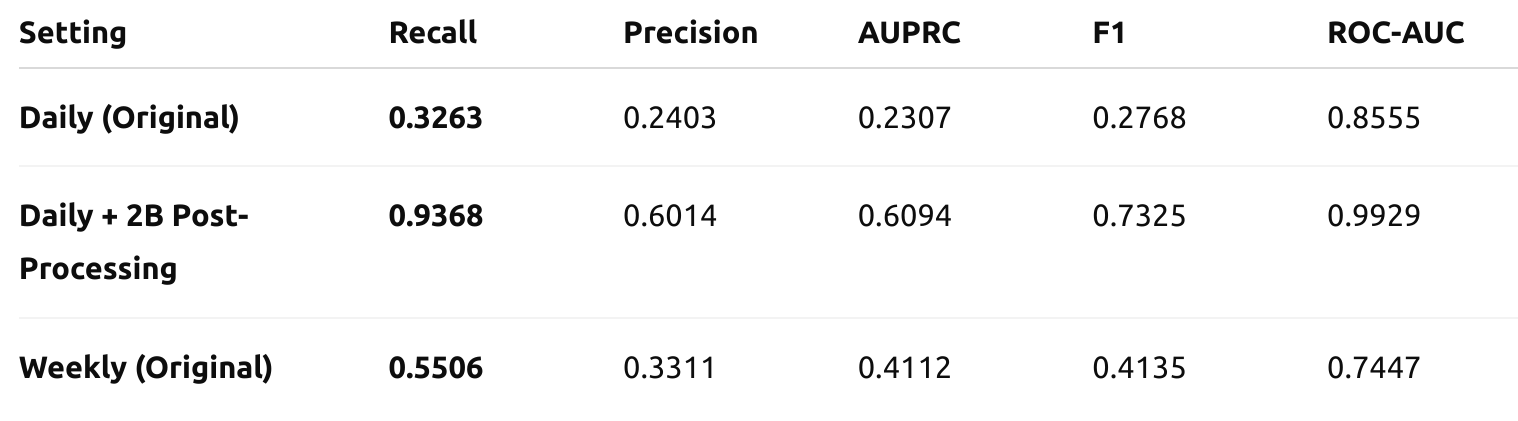

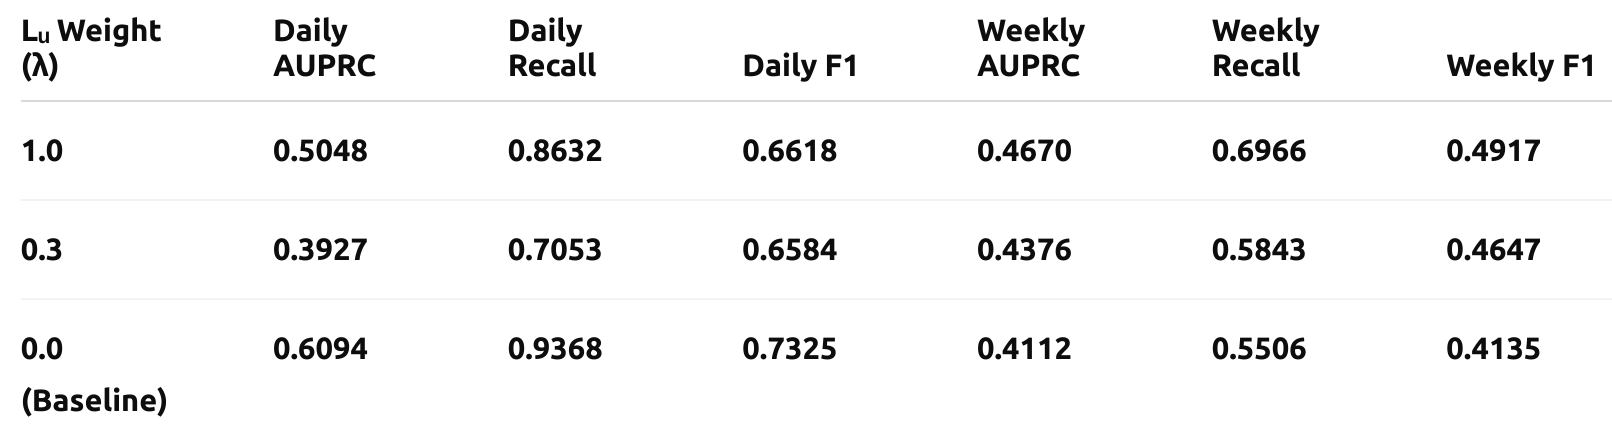